In [2]:
import pandas as pd
df = pd.read_csv("diabetes_data.csv")

In [3]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,173,32,22,86,29.4,0.221,21,1
1,144,64,0,123,33.0,0.245,24,1
2,115,74,0,82,19.9,0.653,41,0
3,116,60,0,50,36.1,0.238,21,0
4,149,68,0,0,29.7,0.979,21,1


In [4]:
df.shape

(768, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [6]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.110677,66.731771,14.509115,42.180990,32.221745,0.475345,35.419271,0.350260
std,31.420635,21.916897,15.698177,69.953662,7.691336,0.457390,16.932375,0.477362
min,44.000000,0.000000,0.000000,0.000000,18.000000,0.078000,21.000000,0.000000
25%,100.000000,54.000000,0.000000,0.000000,27.000000,0.122750,21.000000,0.000000
50%,121.000000,68.000000,10.000000,0.000000,31.550000,0.317500,29.000000,0.000000
75%,142.250000,80.000000,26.000000,62.250000,37.725000,0.660750,44.250000,1.000000
max,199.000000,122.000000,64.000000,474.000000,56.100000,2.420000,81.000000,1.000000


In [7]:
# df.isnull().sum()
df.isna().sum()

Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
(df == 0).sum()

Glucose                       0
BloodPressure                24
SkinThickness               298
Insulin                     390
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     499
dtype: int64

In [9]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,173,32,22,86,29.4,0.221,21,1
1,144,64,0,123,33.0,0.245,24,1
2,115,74,0,82,19.9,0.653,41,0
3,116,60,0,50,36.1,0.238,21,0
4,149,68,0,0,29.7,0.979,21,1


In [10]:
df.Outcome.value_counts()

Outcome
0    499
1    269
Name: count, dtype: int64

<Axes: xlabel='Outcome'>

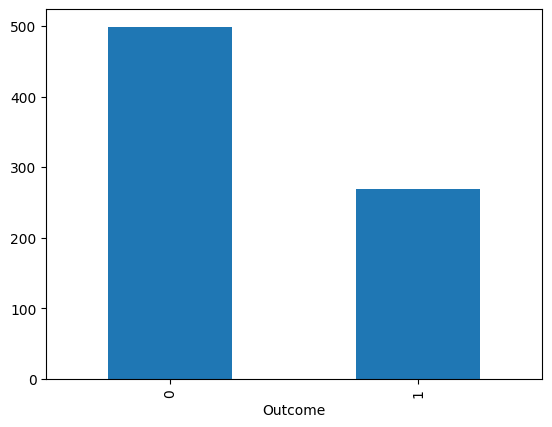

In [11]:
df.Outcome.value_counts().plot(kind="bar")

In [12]:
df.columns[:-1]

Index(['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

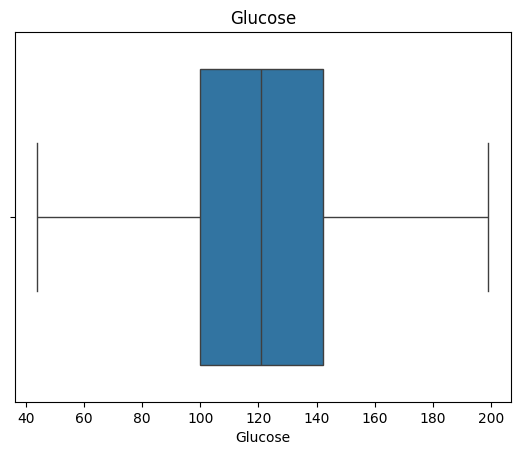

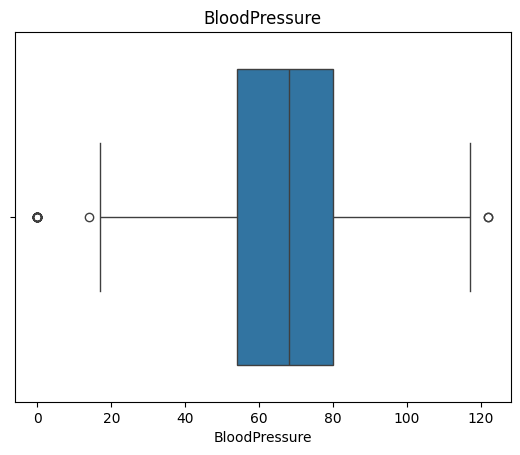

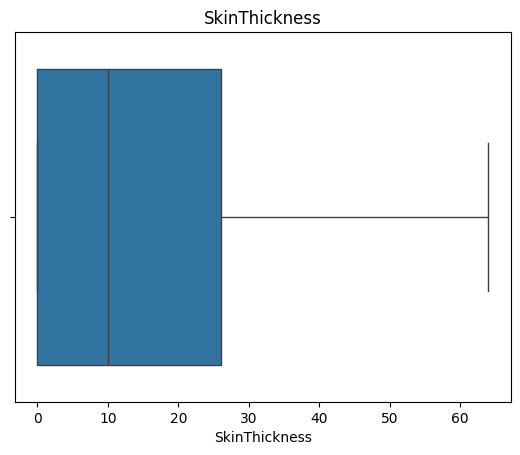

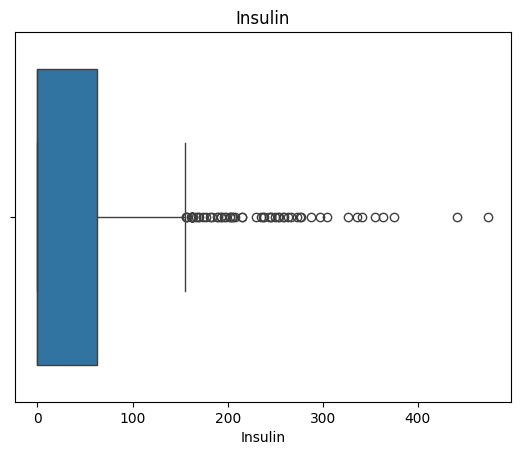

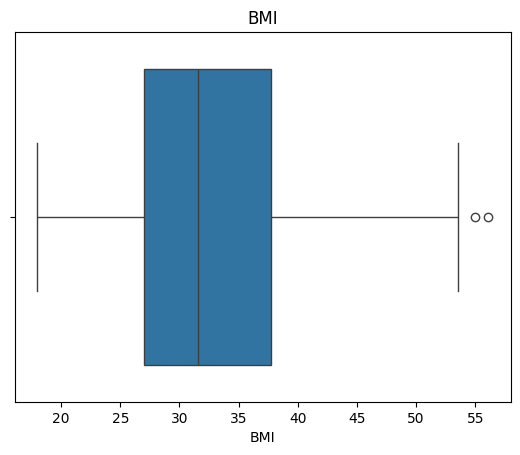

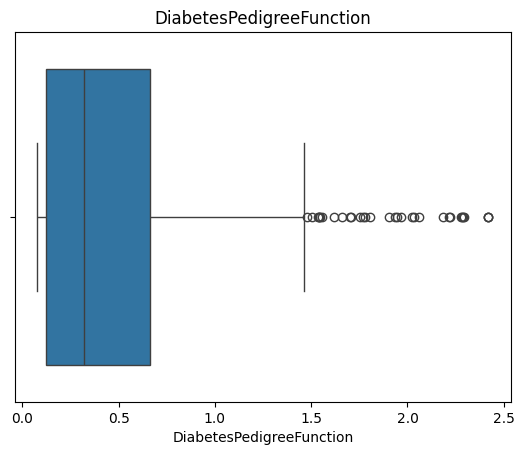

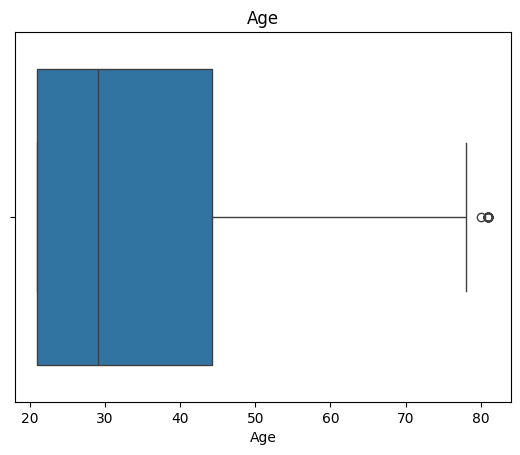

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in df.columns[:-1]:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
x = df.drop('Outcome', axis=1)
y = df.Outcome

In [15]:
x.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,173,32,22,86,29.4,0.221,21
1,144,64,0,123,33.0,0.245,24
2,115,74,0,82,19.9,0.653,41
3,116,60,0,50,36.1,0.238,21
4,149,68,0,0,29.7,0.979,21


In [16]:
y.head()

0    1
1    1
2    0
3    0
4    1
Name: Outcome, dtype: int64

In [19]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
                                    x, y, test_size=0.20)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [23]:
x_train.shape[1]

7

In [27]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [28]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.fit(x_train, y_train, epochs=50, batch_size=8)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5293 - loss: 0.6887
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7182 - loss: 0.6220
Epoch 3/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7394 - loss: 0.5671
Epoch 4/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7704 - loss: 0.5113
Epoch 5/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8078 - loss: 0.4557
Epoch 6/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8274 - loss: 0.4045
Epoch 7/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.3711
Epoch 8/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8371 - loss: 0.3552
Epoch 9/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8388 - loss: 0.3457
Epoch 10/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8420 - loss: 0.3401
Epoch 11/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8404 - loss: 0.3369
Epoch 12/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8518 - lo

In [30]:
model.evaluate(x_test, y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9156 - loss: 0.2764 


[0.2763628661632538, 0.9155844449996948]

In [32]:
x.head(0)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age


In [ ]:
new_data = [[120, 80, 20, 85, 29, 0.5, 31]]

new_data = scaler.transform(new_data)

In [34]:
new_data

array([[-0.02109579,  0.60135173,  0.30701819,  0.64519949, -0.40058075,
         0.05689279, -0.26612638]])

In [37]:
pred = model.predict(new_data)
print(pred)

if pred > 0.5:
    print("Diabetes")
else:
    print("No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
[[0.3245927]]
No Diabetes


In [39]:
df.head(0)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [40]:
new_data = [[160, 80, 25, 150, 35.0, 1.2, 45]]

new_data = scaler.transform(new_data)
new_data

c:\Users\visha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[1.26136107, 0.60135173, 0.62448058, 1.61225969, 0.40315515,
        1.59983336, 0.55973007]])

In [41]:
pred = model.predict(new_data)
print(pred)

if pred > 0.5:
    print("Diabetes")
else:
    print("No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[0.9956857]]
Diabetes


In [42]:
df.head(0)

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [43]:
new_data = [[90, 70, 18, 70, 22.0, 0.2, 25]]

new_data = scaler.transform(new_data)
new_data

c:\Users\visha\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.98293844,  0.15079656,  0.18003323,  0.42203176, -1.33827265,
        -0.60436745, -0.62006486]])

In [44]:
pred = model.predict(new_data)
print(pred)

if pred > 0.5:
    print("Diabetes")
else:
    print("No Diabetes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
[[0.00111207]]
No Diabetes
